In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

# **SECTION 4: OPTION PRICING**
## **4.1. PRICING AND HEDGING VANILLA OPTIONS WITH THE BINOMIAL TREE**

In this lecture, we will learn how to write a Python function to construct a simple binomial tree.

#### Generating the price paths

In [3]:
def binomial_tree(S_ini, T, u, d, N):
    """
    Args:
    - S_ini: Initial underlying price (S_0)
    - T: Time to maturity (time horizone in years)
    - u: upward price multiplier
    - d: downward price multiplier
    - N: Number of time steps.
    """
    S = np.zeros([N + 1, N + 1])  # Underlying price paths
    for i in range(0, N + 1):
        S[N, i] = S_ini * (u ** (i)) * (d ** (N - i)) #terminal nodes
    for j in range(N - 1, -1, -1):
        for i in range(0, j + 1):
            S[j, i] = S_ini * (u ** (i)) * (d ** (j - i)) #middle nodes 
            # S[j, i] represents the price at step j (period j = 1, ... N) after i up moves and j - i down moves.
    return S


In [4]:
S_paths = binomial_tree(100, 1, 1.15, 0.85, 2)
S_paths

array([[100.  ,   0.  ,   0.  ],
       [ 85.  , 115.  ,   0.  ],
       [ 72.25,  97.75, 132.25]])

### **4.1.1. European Call Option**

Strike: $K = \$ 90$;

Maturity: $T = 1$ year;

The payoff is computed at maturity (at terminal nodes).

#### Call payoff function:

In [5]:
def binomial_tree_call(S_ini, K, T, u, d, N):
    """
    Args:
    - S_ini: Initial underlying price (S_0)
    - K: Call option's Strike price
    - T: Time to maturity (time horizone in periods)
    - u: upward price multiplier
    - d: downward price multiplier
    - N: Number of time steps.
    """
    C = np.zeros([N + 1, N + 1])  # Call payoff
    S = np.zeros([N + 1, N + 1])  # Underlying price
    for i in range(0, N + 1):
        C[N, i] = max(S_ini * (u ** (i)) * (d ** (N - i)) - K, 0) # Call Option payoff at terminal nodes.
        S[N, i] = S_ini * (u ** (i)) * (d ** (N - i)) # Price at terminal
    for j in range(N - 1, -1, -1):
        for i in range(0, j + 1):
            S[j, i] = S_ini * (u ** (i)) * (d ** (j - i))
    return S, C

In [6]:
S_paths, Call = binomial_tree_call(100, 90, 3, 1.15, 0.85, 3)
print("Underlying Price Evolution:\n", S_paths)
print("\n Call Option Payoff:\n", Call)

Underlying Price Evolution:
 [[100.       0.       0.       0.    ]
 [ 85.     115.       0.       0.    ]
 [ 72.25    97.75   132.25     0.    ]
 [ 61.4125  83.0875 112.4125 152.0875]]

 Call Option Payoff:
 [[ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.      0.      0.    ]
 [ 0.      0.     22.4125 62.0875]]


#### **Risk-Neutral Probabilities**
#### One-step backward induction for valuation of Call Option:

- Risk-neutral probability is calculated at one-step tree: $$p = \frac{e^r_f \partial t - d}{u - d}$$
- At each node $[j,i]$ ($j$ steps with i steps up and $j-i$ steps down): the option price is computed backward: discounted from its expected price in the next steps:
$$ C_{j, i} = e^{-r_f \partial t} \left[ p C_{j+1, i+1} + (1-p) C_{j + 1, i} \right]$$

In [8]:
def binomial_call_full(S_ini, K, T, r, u, d, N):
    """
    Args:
    - S_ini: Initial underlying price (S_0)
    - K: Call option's Strike price
    - T: Time to maturity (time horizone in periods)
    - r: risk-free rate
    - u: upward price multiplier
    - d: downward price multiplier
    - N: Number of time steps.
    """
    dt = T / N  # Define time step to calculate discounted rate
    p = (np.exp(r * dt) - d) / (u - d)  # Risk neutral probabilities (probs)
    C = np.zeros([N + 1, N + 1])  # Call prices/payoff
    S = np.zeros([N + 1, N + 1])  # Underlying price
    for i in range(0, N + 1):
        C[N, i] = max(S_ini * (u ** (i)) * (d ** (N - i)) - K, 0) #start from call payoff at maturity 
        S[N, i] = S_ini * (u ** (i)) * (d ** (N - i))
    for j in range(N - 1, -1, -1):
        for i in range(0, j + 1):
            C[j, i] = np.exp(-r * dt) * (p * C[j + 1, i + 1] + (1 - p) * C[j + 1, i]) # Call price at each non-terminal node.
            S[j, i] = S_ini * (u ** (i)) * (d ** (j - i))
    return C[0, 0], C, S

In [9]:
call_price, C_paths, S_paths = binomial_call_full(100, 90, 10, 0, 1.15, 0.85, 3)
print("Underlying Price Evolution:\n", S_paths)
print("\n Call Option Payoff:\n", C_paths)
print("\n Call Option Price at t=0: ", "{:.2f}".format(call_price))

Underlying Price Evolution:
 [[100.       0.       0.       0.    ]
 [ 85.     115.       0.       0.    ]
 [ 72.25    97.75   132.25     0.    ]
 [ 61.4125  83.0875 112.4125 152.0875]]

 Call Option Payoff:
 [[16.165625  0.        0.        0.      ]
 [ 5.603125 26.728125  0.        0.      ]
 [ 0.       11.20625  42.25      0.      ]
 [ 0.        0.       22.4125   62.0875  ]]

 Call Option Price at t=0:  16.17


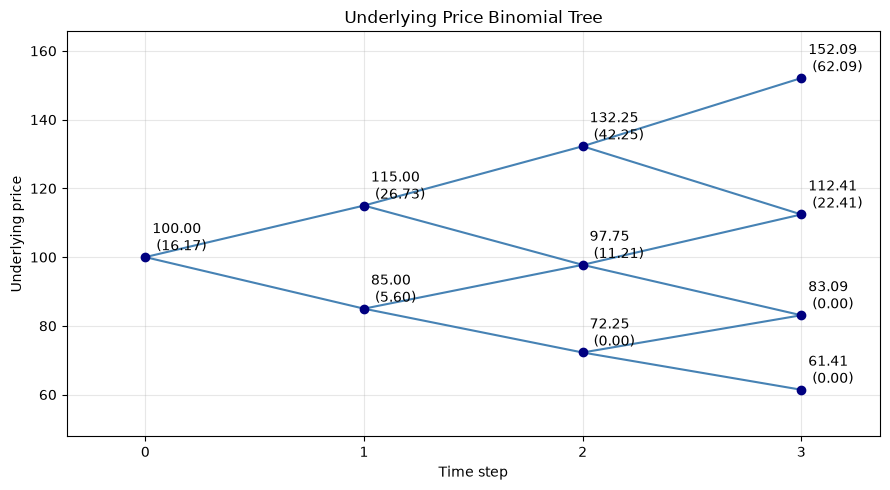

In [ ]:
# Below plot code snippet is created by AI 
N = S_paths.shape[0] - 1

fig, ax = plt.subplots(figsize=(9, 5))

# Connect each node to its down and up successors
for j in range(N):
    for i in range(j + 1):
        price = S_paths[j, i]

        ax.plot(
            [j, j + 1],
            [price, S_paths[j + 1, i]],
            color="steelblue"
        )
        ax.plot(
            [j, j + 1],
            [price, S_paths[j + 1, i + 1]],
            color="steelblue"
        )

# Draw and label valid nodes only
for j in range(N + 1):
    for i in range(j + 1):
        price = S_paths[j, i]
        call_p = C_paths[j,i]
        ax.scatter(j, price, color="navy", zorder=3)
        ax.annotate(
            f"{price:.2f} \n ({call_p:.2f})",
            (j, price),
            xytext=(5, 5),
            textcoords="offset points"
        )

ax.set(
    title="Underlying Price Binomial Tree",
    xlabel="Time step",
    ylabel="Underlying price"
)
ax.set_xticks(range(N + 1))
ax.margins(x=0.12, y=0.15)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **4.1.1. European Put Option**

Your turn: Compute the price of put option at $t = 0$ with strike $K =90$ and maturity $T=1$ year, for a 3-step tree.

In [ ]:
def binomial_put_full(S_ini, K, T, r, u, d, N):
    """
    Args:
    - S_ini: Initial underlying price (S_0)
    - K: Put option's Strike price
    - T: Time to maturity (time horizone in periods)
    - r: risk-free rate
    - u: upward price multiplier
    - d: downward price multiplier
    - N: Number of time steps.
    """
    dt = T / N  # Define time step to calculate discounted rate
    p = (np.exp(r * dt) - d) / (u - d)  # Risk neutral probabilities (probs)
    Put = np.zeros([N + 1, N + 1])  # Put prices/payoff
    S = np.zeros([N + 1, N + 1])  # Underlying price
    for i in range(0, N + 1):
        Put[N, i] = ... #Your turn: Put payoff at maturity 
        S[N, i] = S_ini * (u ** (i)) * (d ** (N - i))
    for j in range(N - 1, -1, -1):
        for i in range(0, j + 1):
            Put[j, i] = np.exp(-r * dt) * (p * Put[j + 1, i + 1] + (1 - p) * Put[j + 1, i]) # Put price at each non-terminal node.
            S[j, i] = S_ini * (u ** (i)) * (d ** (j - i))
    return Put[0, 0], Put, S

In [13]:
put_price, P_paths, S_paths = binomial_put_full(100, 90, 10, 0, 1.15, 0.85, 3)
print("Underlying Price Evolution:\n", S_paths)
print("\n Put Option Payoff:\n", P_paths)
print("\n Put Option Price at t=0: ", "{:.2f}".format(put_price))

NameError: name 'binomial_put_full' is not defined